# Spectrum Adapted EM algorithmによるスペクトルデータフィット
このノートは、pythonコードであるEMPeaksの利用法に関するチュートリアルです。このパッケージのversiton 2.0では、
スペクトルデータを種々のモデル関数（混合ガウス分布, 混合ローレンツ分布, 混合擬フォークト分布, 混合ドニアクシューニッチ分布）
でフィッティングするためのツールです。
 
フィッティングにはスペクトル解析用EMアルゴリズム[Sci. Tech. Adv. Mater. 20, 733-735 (2019)]を用います。
verson2では、混合ガウス分布に加えて混合ローレンツ分布, 混合擬フォークト分布, 混合Doniach-Sunijic分布に対応しました。
詳しくは[STAM-M 1, 45-55 (2021).]を参考にしてください。

通常のEMアルゴリズムをこの問題に適用する場合、
データはn番目のイベントでの観測エネルギー$E_n$に対する集合$E_{\rm 1D}=\{E_n\}_{n=1}^{N}$を用いますが、
スペクトル解析用では$E_{\rm 1D}$をヒストグラム形式にしたデータ
$E_{\rm 2D} = \{E^{\rm bin}_n, w_n\}_{n=1}^{N_{\rm bin}}$を用います。
ただし、$E_n^{\rm bin}$はチャネル$n$のエネルギー値, $w_n$はチャネル$n$の重み, $N_{\rm bin}$はチャネル数です。

混合モデルの成分数Kはデフォルトでは２に設定されていますが、任意の正の整数に設定することができます。
成分数の最適化は周辺尤度を活用した方法や情報量基準を用いたものが考えられますが、現時点では実装されていませんのでご注意ください。

## チュートリアルの内容
0. パッケージのインストール
1. Lorentzian Mixture Model(LMM) によるフィッティング
2. Pseudo-Voigt Mixture Model(PVMM) によるフィッティング
3. Doniach-Sunijic Micture Model (DSMM) によるフィッティング

## 0. パッケージのインストールとパス設定
本パッケージは、PyPIにアップロードされいるため、`pip`コマンドでシステムに導入することができます。

`$pip install EMPeaks`

もしインストールがうまくいかない場合、もしくは直接モジュールにパスを通したい場合には、以下の手順をふんでください。
   1. 配布パッケージの中にあるEMPeaksフォルダをモジュール置き場に移してください。
   2. モジュール置き場のフルパスを記録してください。<br>
     （参照：mac: https://aprico-media.com/posts/1578/ ,windows: https://windows-podcast.com/sundayprogrammer/archives/80 ）
   3. jupyter notebookで以下のセルを実行してください（setup.pyを使った場合には不要です。）
      ``` python
         import sys
         sys.path.append("フルパス")
      ```
Windowsの場合、パス区切りがバックスラッシュ"\\"で表示されます。バックスラッシュはエスケープされてしまうため、全てスラッシュ"/"で置き換えてください。これでも問題なく読み込みます。

これで本パッケージを使用する準備が整いました。

## テスト1. Lorentzian Mixture Model(LMM) によるフィッティング

/Users/yasunobu/Documents/GitHub/EMPeaks/EMPeaks/LorentzianMixture/_lorentz.py:146: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if len(_opt_x0) is 0:
/Users/yasunobu/Documents/GitHub/EMPeaks/EMPeaks/LorentzianMixture/_lorentz.py:152: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  elif len(_opt_x0) is not 1:


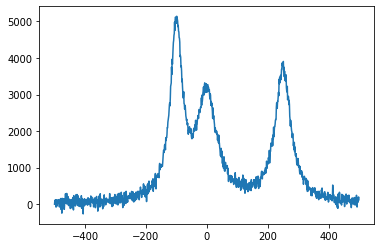

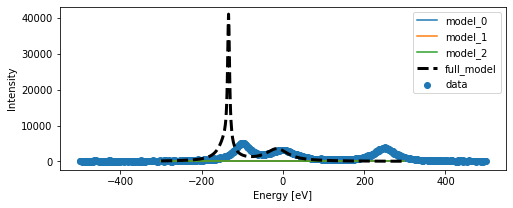

* Starting Trial #   0
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter.  61, elapsed time  1.00 s
   LogLikelihood:     -6.27589990e+06
        residual:      8.96600019e-09
<< Optimizing normalization factor by using least square method. >>
init 998690.8716783227
   non-linear least-square optimization is successfully finished.
            RMSE:      9.819262e+01
    Elapsed time:      1.578093e-03 s

* Starting Trial #   1
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter.  22, elapsed time  0.39 s
   LogLikelihood:     -6.27589989e+06
        residual:      8.86743039e-09
<< Optimizing normalization factor by using least square method. >>
init 998690.8716783227
   non-linear least-square optimization is successfully finished.
            RMSE:      9.821230e+01
    Elapsed time:      1.356125e-03 s

* Starting Trial #   2
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter.  36, elapsed time  0.71 s


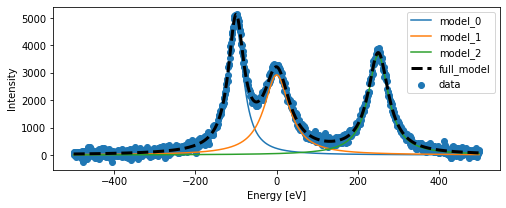

In [1]:
%matplotlib inline
from EMPeaks import LorentzianMixture
import numpy as np
import matplotlib.pyplot as plt
#フィットするためのデータを生成します
lmm_data = LorentzianMixture.LorentzianMixtureModel(K=3)
lmm_data.model[0].x0 =-100
lmm_data.model[1].x0 = 250
lmm_data.model[2].x0 = 0

#データと初期パラメータのモデルをプロットします
x = np.arange(-500, 500)
N = 1.0e+6
y = N * (lmm_data.predict(x) + np.random.randn(len(x)) * 1.e-4)
plt.plot(x,y)
lmm = LorentzianMixture.LorentzianMixtureModel(K=3)
lmm.N_tot = sum(y)
lmm.plot(x,y)

#5回の初期パラメータサンプリングのあとに得られた最適なモデルをプロットします。
lmm.sampling(x,y,trial=5, r_eps=1e-8)
#lmm.fit(x, y, r_eps=1e-10)
lmm.plot(x,y)

## テスト2. Pseudo-Voigt Mixture Model(PVMM) によるフィッティング

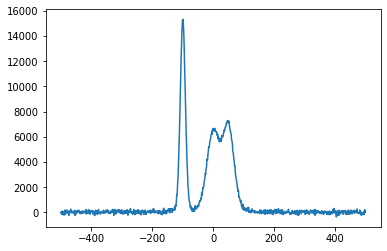

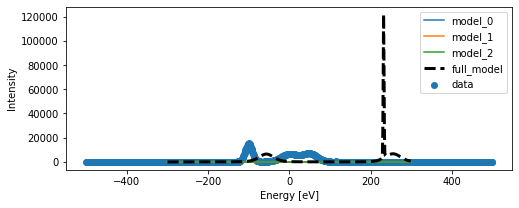

* Starting Trial #   0
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter. 317, elapsed time 26.57 s
   LogLikelihood:     -5.24312477e+06
        residual:      9.85312647e-09
<< Optimizing normalization factor by using least square method. >>
init 1005154.2362842944
   non-linear least-square optimization is successfully finished.
            RMSE:      1.062505e+02
    Elapsed time:      5.212069e-03 s

* Starting Trial #   1
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter. 115, elapsed time  8.26 s
   LogLikelihood:     -5.24312484e+06
        residual:      9.74476972e-09
<< Optimizing normalization factor by using least square method. >>
init 1005154.2362842944
   non-linear least-square optimization is successfully finished.
            RMSE:      1.063315e+02
    Elapsed time:      6.439924e-03 s

* Starting Trial #   2
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter. 662, elapsed time 53.63 

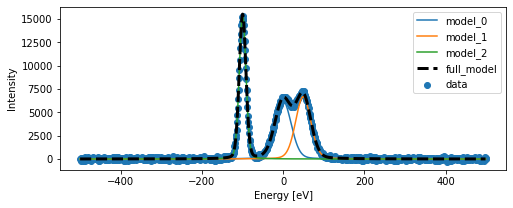

In [2]:
%matplotlib inline
from EMPeaks import PseudoVoigtMixture
import numpy as np
import matplotlib.pyplot as plt
#フィットするためのデータを生成します
pvmm_data = PseudoVoigtMixture.PseudoVoigtMixtureModel(K=3)
pvmm_data.model[0].x0 =-100
pvmm_data.model[1].x0 = 50
pvmm_data.model[2].x0 = 0

#データと初期パラメータのモデルをプロットします
N = 1.0e+6
x = np.arange(-500, 500)
y = N * (pvmm_data.predict(x) + np.random.randn(len(x)) * 1.e-4)
plt.plot(x,y)
pvmm = PseudoVoigtMixture.PseudoVoigtMixtureModel(K=3)
pvmm.N_tot = sum(y)
pvmm.plot(x,y)

#5回の初期パラメータサンプリングのあとに得られた最適なモデルをプロットします。
pvmm.sampling(x,y,trial=5, r_eps=1e-8)
#pvmm.fit(x, y, r_eps=5e-8)
pvmm.plot(x,y)

## 3. Doniach-Sunijic Micture Model (DSMM) によるフィッティング

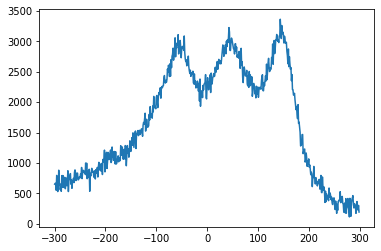

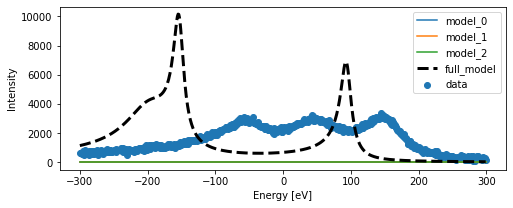

* Starting Trial #   0
<< Start fitting via Adapted EM Algorithm. >>
>>> Convergence is not achieved within the iteration of 1000, elapsed time: 11.54 s
   LogLikelihood:      -6.25084856e+06
        residual:       1.67471998e-08
<< Optimizing normalization factor by using least square method. >>
init 1002242.6085513706
   non-linear least-square optimization is successfully finished.
            RMSE:      9.401786e+01
    Elapsed time:      2.274990e-03 s

* Starting Trial #   1
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at iter. 146, elapsed time  1.23 s
   LogLikelihood:     -6.26159163e+06
        residual:      9.66784288e-09
<< Optimizing normalization factor by using least square method. >>
init 1002242.6085513706
   non-linear least-square optimization is successfully finished.
            RMSE:      3.036668e+02
    Elapsed time:      2.337933e-03 s

* Starting Trial #   2
<< Start fitting via Adapted EM Algorithm. >>
Convergence is achieved at ite

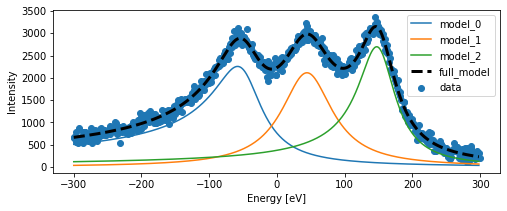

In [3]:
%matplotlib inline
from EMPeaks import DoniachSunjicMixture
import numpy as np
import matplotlib.pyplot as plt
#フィットするためのデータの元となるモデルを生成します
dsmm_data = DoniachSunjicMixture.DoniachSunjicMixtureModel(K=3)
dsmm_data.model[0].x0 =  50.0
dsmm_data.model[1].x0 = 150.0
dsmm_data.model[2].x0 = -50.0

#生成したデータと初期モデルをプロットします
N = 1.e+6
x = np.arange(-300, 300)
y = dsmm_data.predict(x) * N + np.random.randn(len(x)) * 1.e-4 * N
plt.plot(x,y)
dsmm = DoniachSunjicMixture.DoniachSunjicMixtureModel(K=3)
dsmm.N_tot = sum(y)
dsmm.plot(x,y)

#5回の初期パラメータサンプリングのあとに得られた最適なモデルをプロットします。
dsmm.sampling(x,y,trial=5, r_eps=1e-8)
#dsmm.fit(x, y, r_eps=1e-8)
dsmm.plot(x,y)